In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "master_US.csv"

df = pd.read_csv(CSV_PATH)
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Keep all columns originally
data = df.copy()

print(data.head())

print(data.info())

        DATE  working_hour_manuf    CPI  Ids_Prd  R_Csump  Ef_Fed_Rate  \
0 1960-01-01                40.6  29.37  24.2078   15.789         3.99   
1 1960-02-01                40.3  29.41  23.9924   15.858         3.97   
2 1960-03-01                40.0  29.41  23.7770   16.083         3.84   
3 1960-04-01                40.0  29.54  23.5885   16.331         3.92   
4 1960-05-01                40.1  29.57  23.5616   16.002         3.85   

   Intr_10Y  Unemp     M2     M1  Labor_partic  Per_savings  All_Emp  \
0      4.72    5.2  298.2  140.0          59.1         10.9    54274   
1      4.49    4.8  298.4  139.9          59.1         10.6    54513   
2      4.25    5.4  299.3  139.8          58.5          9.4    54454   
3      4.28    5.2  300.1  139.6          59.5          8.4    54813   
4      4.35    5.1  300.9  139.6          59.5         10.4    54475   

   Moody_aaa  NetExports      ^GSPC  Real GDP  Customs_Duties  Imports_Goods  \
0       4.61         NaN  58.029000  3517.

In [16]:
# create tariff rate raw number, only quarterly though
data["tariff_rate_raw"] = data["Customs_Duties"] / data["Imports_Goods"]

#filter data just for after 2000
current_data = data.where(data["DATE"] >= "1999-01-01")

#some command so that we dont fill with all nas
current_data = current_data.dropna(subset=["DATE"]).reset_index(drop=True)

# fill in blanks using linear method
current_data["tariff_rate"] = current_data["tariff_rate_raw"].interpolate(method = "linear")
current_data["Customs_Duties"] = current_data["Customs_Duties"].interpolate(method = "linear")
current_data["Imports_Goods"] = current_data["Imports_Goods"].interpolate(method = "linear")
current_data["GDP_nominal"] = current_data["GDP_nominal"].interpolate(method = "linear")
current_data["Real GDP"] = current_data["Real GDP"].interpolate(method = "linear")

print(current_data.head())

        DATE  working_hour_manuf    CPI  Ids_Prd  R_Csump  Ef_Fed_Rate  \
0 1999-01-01                41.3  164.7  87.4949   64.013         4.63   
1 1999-02-01                41.4  164.7  88.0270   64.316         4.76   
2 1999-03-01                41.3  164.8  88.2267   64.624         4.81   
3 1999-04-01                41.3  165.9  88.4295   65.011         4.74   
4 1999-05-01                41.4  166.0  88.9886   65.311         4.74   

   Intr_10Y  Unemp      M2      M1  ...   All_Emp  Moody_aaa  NetExports  \
0      4.72    4.3  4403.0  1098.1  ...  127699.0       6.24     78473.0   
1      5.00    4.4  4425.8  1096.7  ...  128117.0       6.40     78212.0   
2      5.23    4.2  4432.6  1096.6  ...  128234.0       6.62     78701.0   
3      5.18    4.3  4461.4  1101.6  ...  128595.0       6.64     79530.0   
4      5.54    4.2  4486.1  1103.8  ...  128813.0       6.93     79539.0   

         ^GSPC      Real GDP  Customs_Duties  Imports_Goods  GDP_nominal  \
0  1248.774735  13315.

In [ ]:
forecast_horizon = 12
current_data["cpi_future"] = current_data["CPI"].shift(-forecast_horizon)
current_data["cpi_future_change"] = current_data["cpi_future"] - current_data["CPI"]

current_data["tau_lag_3"]  = current_data["tariff_rate"].shift(3)
current_data["tau_lag_6"]  = current_data["tariff_rate"].shift(6)
current_data["tau_lag_12"] = current_data["tariff_rate"].shift(12)

current_data["cpi_lag_3"]  = current_data["CPI"].shift(1)
current_data["cpi_lag_6"]  = current_data["CPI"].shift(3)
current_data["cpi_lag_12"] = current_data["CPI"].shift(12)

# Anomaly dummy (2008 crisis in train, COVID in val)
current_data["anomaly"] = (
    ((current_data["DATE"] >= "2008-09-01") & (current_data["DATE"] <= "2009-12-01")) |
    ((current_data["DATE"] >= "2020-03-01") & (current_data["DATE"] <= "2021-12-01"))
).astype(int)
current_data["anomaly_lag_12"] = current_data["anomaly"].shift(12).fillna(0).astype(int)

century_data = current_data.where(current_data["DATE"] >= "2000-01-01")
century_data = century_data.dropna(subset=["DATE"]).reset_index(drop=True)
print(century_data.head())

        DATE  working_hour_manuf    CPI  Ids_Prd  R_Csump  Ef_Fed_Rate  \
0 2000-01-01                41.5  169.3  91.5380   67.481         5.45   
1 2000-02-01                41.5  170.0  91.8239   68.116         5.73   
2 2000-03-01                41.4  171.0  92.1504   68.451         5.85   
3 2000-04-01                41.6  170.9  92.6989   68.431         6.02   
4 2000-05-01                41.2  171.2  92.9499   68.688         6.27   

   Intr_10Y  Unemp      M2      M1  ...  cpi_future  cpi_future_change  \
0      6.66    4.0  4667.6  1122.1  ...       175.6                6.3   
1      6.52    4.1  4680.9  1108.6  ...       176.0                6.0   
2      6.26    4.0  4711.7  1107.5  ...       176.1                5.1   
3      5.99    3.8  4767.8  1115.6  ...       176.4                5.5   
4      6.44    4.0  4755.7  1104.9  ...       177.3                6.1   

   tau_lag_3  tau_lag_6  tau_lag_12  cpi_lag_3  cpi_lag_6  cpi_lag_12  \
0   0.018627   0.018294    0.018608  

In [18]:
#for random split
'''target_col = "cpi_future"

feature_cols = [col for col in century_data.columns if col not in ["DATE", target_col]]

model_data = century_data[["DATE"] + feature_cols + [target_col]].dropna().reset_index(drop=True)

X = model_data[feature_cols]
y = model_data[target_col]
dates = model_data["DATE"]

print(X.isna().sum().sum(), y.isna().sum())
print("Number of features:", len(feature_cols))
print(feature_cols)

#for chronological split
'''
target_col   = "cpi_future_change"
exclude_cols = ["DATE", "cpi_future", "cpi_future_change", "tariff_rate_raw"]
feature_cols = [col for col in century_data.columns if col not in exclude_cols]

X = century_data[feature_cols]
y = century_data[target_col]

print("Number of features:", len(feature_cols))
print(feature_cols)



Number of features: 28
['working_hour_manuf', 'CPI', 'Ids_Prd', 'R_Csump', 'Ef_Fed_Rate', 'Intr_10Y', 'Unemp', 'M2', 'M1', 'Labor_partic', 'Per_savings', 'All_Emp', 'Moody_aaa', 'NetExports', '^GSPC', 'Real GDP', 'Customs_Duties', 'Imports_Goods', 'GDP_nominal', 'tariff_rate', 'tau_lag_3', 'tau_lag_6', 'tau_lag_12', 'cpi_lag_3', 'cpi_lag_6', 'cpi_lag_12', 'anomaly', 'anomaly_lag_12']


In [57]:
# creating split based on chronological order
n = len(century_data)

#create 70 train, 20 validation, 10 test
train_end = int(n * 0.7)
val_end = int(n * 0.9)

#for feature columns
X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

#for date column
dates_train = century_data["DATE"].iloc[:train_end]
dates_val = century_data["DATE"].iloc[train_end:val_end]
dates_test = century_data["DATE"].iloc[val_end:]

In [58]:
'''from sklearn.model_selection import train_test_split

#split not chronologically and use a random state - learning to deal with times like COVID

# first split: 70% train, 30% temp
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp, dates_train, dates_temp = train_test_split(
    X,
    y,
    dates,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test, dates_val, dates_test = train_test_split(
    X_temp,
    y_temp,
    dates_temp,
    test_size=1/3,
    random_state=42,
    shuffle=True
)


print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print(X_train)'''


'from sklearn.model_selection import train_test_split\n\n#split not chronologically and use a random state - learning to deal with times like COVID\n\n# first split: 70% train, 30% temp\nfrom sklearn.model_selection import train_test_split\n\nX_train, X_temp, y_train, y_temp, dates_train, dates_temp = train_test_split(\n    X,\n    y,\n    dates,\n    test_size=0.30,\n    random_state=42,\n    shuffle=True\n)\n\nX_val, X_test, y_val, y_test, dates_val, dates_test = train_test_split(\n    X_temp,\n    y_temp,\n    dates_temp,\n    test_size=1/3,\n    random_state=42,\n    shuffle=True\n)\n\n\nprint("Train shape:", X_train.shape)\nprint("Validation shape:", X_val.shape)\nprint("Test shape:", X_test.shape)\nprint(X_train)'

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#scale values
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X Train shape:", X_train_scaled.shape)
print("X Validation shape:", X_val_scaled.shape)
print("X Test shape:", X_test_scaled.shape)
print("y Train shape:", y_train.shape)
print("y Validation shape:", y_val.shape)
print("y Test shape:", y_test.shape)
print(X_train_scaled)


#scaling above is for chronological split
'''
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(X_train_scaled.isna().sum().sum(), y_train.isna().sum())'''


X Train shape: (218, 28)
X Validation shape: (62, 28)
X Test shape: (32, 28)
y Train shape: (218,)
y Validation shape: (62,)
y Test shape: (32,)
     working_hour_manuf       CPI   Ids_Prd   R_Csump  Ef_Fed_Rate  Intr_10Y  \
0              0.538886 -1.804434 -0.928063 -1.905481     1.843474  2.513223   
1              0.538886 -1.774489 -0.867102 -1.833573     1.983267  2.400993   
2              0.388467 -1.731711 -0.797483 -1.795638     2.043177  2.192566   
3              0.689304 -1.735989 -0.680527 -1.797903     2.128051  1.976123   
4              0.087629 -1.723156 -0.627007 -1.768800     2.252866  2.336862   
..                  ...       ...       ...       ...          ...       ...   
213            1.290980  1.503428  1.094766  1.850609    -0.303333 -0.933840   
214            1.441398  1.531576  1.146304  1.913118    -0.298341 -0.941857   
215            0.990142  1.553863  1.188523  2.002579    -0.228445 -0.901774   
216            1.140561  1.598952  1.188118  1.990575  

'\nfrom sklearn.preprocessing import StandardScaler\nimport pandas as pd\n\nscaler = StandardScaler()\n\nX_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)\nX_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)\nX_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)\n\nprint(X_train_scaled.isna().sum().sum(), y_train.isna().sum())'

In [60]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_val_pred_change = xgb_model.predict(X_val_scaled)  # predict CPI change


In [62]:
# Convert predicted change back to CPI level
actual_cpi_now = century_data["CPI"].iloc[train_end:val_end].values
actual_cpi_future = century_data["cpi_future"].iloc[train_end:val_end].values
predicted_cpi     = actual_cpi_now + y_val_pred_change

val_results = pd.DataFrame({
    "DATE":          dates_val.values,
    "actual_cpi":    actual_cpi_future,
    "predicted_cpi": predicted_cpi,
}).sort_values("DATE").reset_index(drop=True)

val_results["error"]     = val_results["predicted_cpi"] - val_results["actual_cpi"]
val_results["abs_error"] = val_results["error"].abs()
val_results["year"]      = pd.to_datetime(val_results["DATE"]).dt.year

print(val_results.drop(columns="year").to_string(index=False))
print("\nPer-year errors:")
print(val_results.groupby("year")[["abs_error"]].agg(["mean", "max"]).round(2))

'''val_results = century_data.iloc[train_end:val_end][["DATE"]].copy()
val_results["actual_cpi"] = y_val.values
val_results["predicted_cpi"] = y_val_pred
val_results["error"] = val_results["predicted_cpi"] - val_results["actual_cpi"]
val_results["abs_error"] = val_results["error"].abs()

print(val_results.to_string(index=False))'''


      DATE  actual_cpi  predicted_cpi      error  abs_error
2018-03-01     254.277     253.677527  -0.599473   0.599473
2018-04-01     255.233     254.748893  -0.484107   0.484107
2018-05-01     255.296     255.082514  -0.213486   0.213486
2018-06-01     255.213     254.996434  -0.216566   0.216566
2018-07-01     255.802     255.096064  -0.705936   0.705936
2018-08-01     256.036     255.569058  -0.466942   0.466942
2018-09-01     256.430     256.105843  -0.324157   0.324157
2018-10-01     257.155     256.803543  -0.351457   0.351457
2018-11-01     257.879     256.622452  -1.256548   1.256548
2018-12-01     258.630     256.853996  -1.776004   1.776004
2019-01-01     259.127     256.677647  -2.449353   2.449353
2019-02-01     259.250     257.512085  -1.737915   1.737915
2019-03-01     258.076     258.510909   0.434909   0.434909
2019-04-01     256.032     259.470860   3.438860   3.438860
2019-05-01     255.802     259.752395   3.950395   3.950395
2019-06-01     257.042     259.751078   

'val_results = century_data.iloc[train_end:val_end][["DATE"]].copy()\nval_results["actual_cpi"] = y_val.values\nval_results["predicted_cpi"] = y_val_pred\nval_results["error"] = val_results["predicted_cpi"] - val_results["actual_cpi"]\nval_results["abs_error"] = val_results["error"].abs()\n\nprint(val_results.to_string(index=False))'

In [63]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string(index=False))


           feature  importance
          Real GDP    0.175386
                M2    0.105007
       tariff_rate    0.085796
     Imports_Goods    0.083735
         tau_lag_3    0.078701
       Ef_Fed_Rate    0.076047
         cpi_lag_6    0.042609
           Ids_Prd    0.039519
           R_Csump    0.034484
        NetExports    0.033304
         Moody_aaa    0.030020
        cpi_lag_12    0.024438
           All_Emp    0.023612
       Per_savings    0.022624
           anomaly    0.018563
         tau_lag_6    0.017401
    Customs_Duties    0.016549
        tau_lag_12    0.016516
               CPI    0.014283
                M1    0.013935
             Unemp    0.012437
         cpi_lag_3    0.007707
             ^GSPC    0.006822
       GDP_nominal    0.006734
working_hour_manuf    0.005793
          Intr_10Y    0.005005
      Labor_partic    0.002974
    anomaly_lag_12    0.000000


In [64]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [65]:
y_val_pred_lasso_change = lasso_model.predict(X_val_scaled)
predicted_cpi_lasso     = actual_cpi_now + y_val_pred_lasso_change

val_results_lasso = pd.DataFrame({
    "DATE":          dates_val.values,
    "actual_cpi":    actual_cpi_future,
    "predicted_cpi": predicted_cpi_lasso,
}).sort_values("DATE").reset_index(drop=True)

val_results_lasso["error"]     = val_results_lasso["predicted_cpi"] - val_results_lasso["actual_cpi"]
val_results_lasso["abs_error"] = val_results_lasso["error"].abs()
val_results_lasso["year"]      = pd.to_datetime(val_results_lasso["DATE"]).dt.year

print("Lasso Validation MAE: ", val_results_lasso["abs_error"].mean().round(3))
print("Lasso Validation RMSE:", np.sqrt((val_results_lasso["error"]**2).mean()).round(3))
print()
print(val_results_lasso.groupby("year")[["abs_error"]].agg(["mean", "max"]).round(2))
print()
print(val_results_lasso.drop(columns="year").to_string(index=False))

Lasso Validation MAE:  12.561
Lasso Validation RMSE: 15.212

     abs_error       
          mean    max
year                 
2018      3.42   5.52
2019      2.46   4.59
2020     10.47  15.79
2021     19.51  22.98
2022     22.68  23.92
2023     20.80  21.77

      DATE  actual_cpi  predicted_cpi      error  abs_error
2018-03-01     254.277     255.736669   1.459669   1.459669
2018-04-01     255.233     257.098971   1.865971   1.865971
2018-05-01     255.296     257.027012   1.731012   1.731012
2018-06-01     255.213     258.267612   3.054612   3.054612
2018-07-01     255.802     258.710197   2.908197   2.908197
2018-08-01     256.036     259.995725   3.959725   3.959725
2018-09-01     256.430     260.472420   4.042420   4.042420
2018-10-01     257.155     262.676263   5.521263   5.521263
2018-11-01     257.879     263.047222   5.168222   5.168222
2018-12-01     258.630     263.105103   4.475103   4.475103
2019-01-01     259.127     263.716552   4.589552   4.589552
2019-02-01     259.2

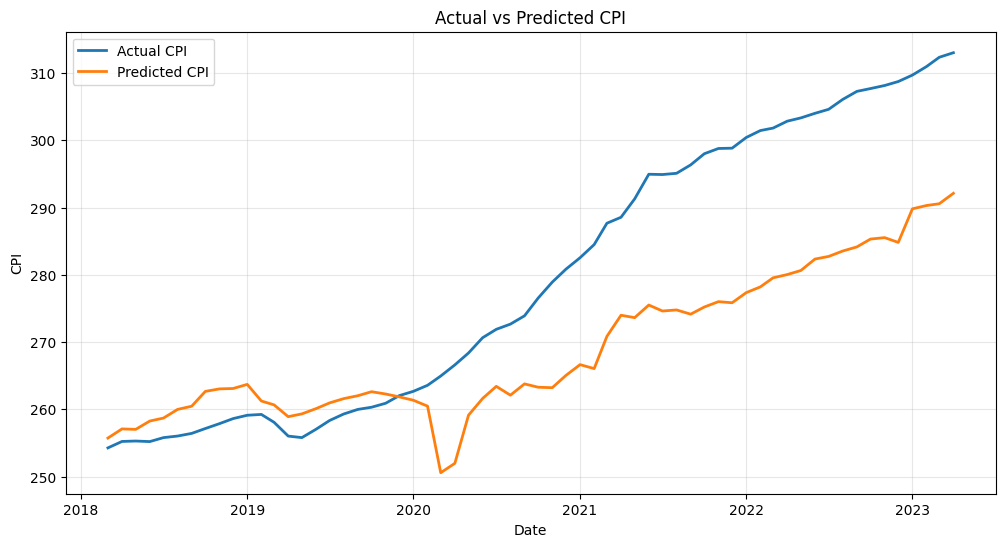

In [66]:
import matplotlib.pyplot as plt

plot_data = val_results_lasso.sort_values("DATE").copy()

plt.figure(figsize=(12, 6))
plt.plot(plot_data["DATE"], plot_data["actual_cpi"], label="Actual CPI", linewidth=2)
plt.plot(plot_data["DATE"], plot_data["predicted_cpi"], label="Predicted CPI", linewidth=2)

plt.title("Actual vs Predicted CPI")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


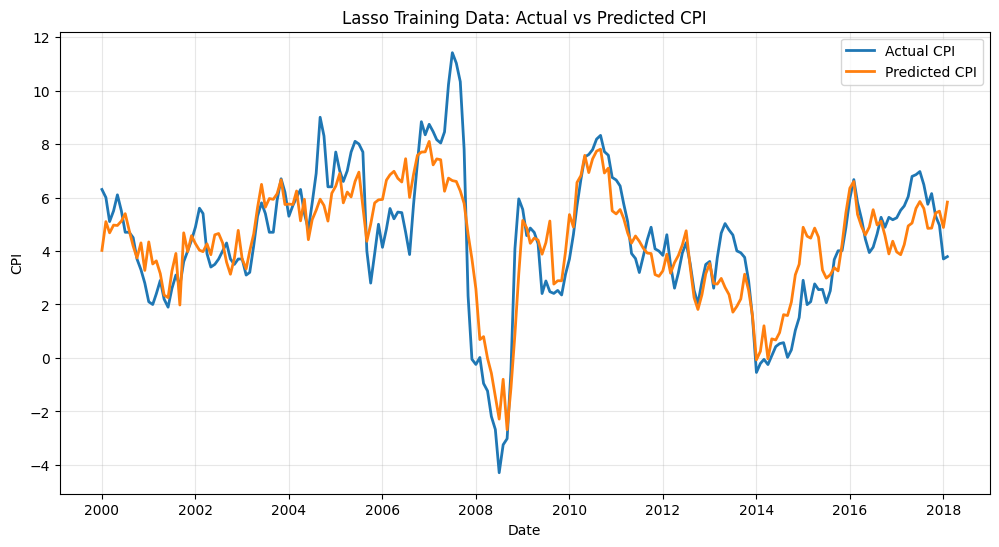

In [67]:
y_train_pred_lasso = lasso_model.predict(X_train_scaled)


train_results_lasso = pd.DataFrame({
    "DATE": dates_train.values,
    "actual_cpi": y_train.values,
    "predicted_cpi": y_train_pred_lasso
}).sort_values("DATE").reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_results_lasso["DATE"], train_results_lasso["actual_cpi"], label="Actual CPI", linewidth=2)
plt.plot(train_results_lasso["DATE"], train_results_lasso["predicted_cpi"], label="Predicted CPI", linewidth=2)

plt.title("Lasso Training Data: Actual vs Predicted CPI")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [68]:
lasso_importance = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": lasso_model.coef_,
    "abs_coefficient": np.abs(lasso_model.coef_)
}).sort_values("abs_coefficient", ascending=False)

lasso_importance

,feature,coefficient,abs_coefficient
1,CPI,-12.973864,12.973864
3,R_Csump,10.419739,10.419739
6,Unemp,3.512645,3.512645
7,M2,2.034546,2.034546
4,Ef_Fed_Rate,1.889273,1.889273
17,Imports_Goods,-1.864550,1.864550
0,working_hour_manuf,1.385613,1.385613
12,Moody_aaa,-0.994118,0.994118
15,Real GDP,0.785597,0.785597
21,tau_lag_6,-0.681723,0.681723


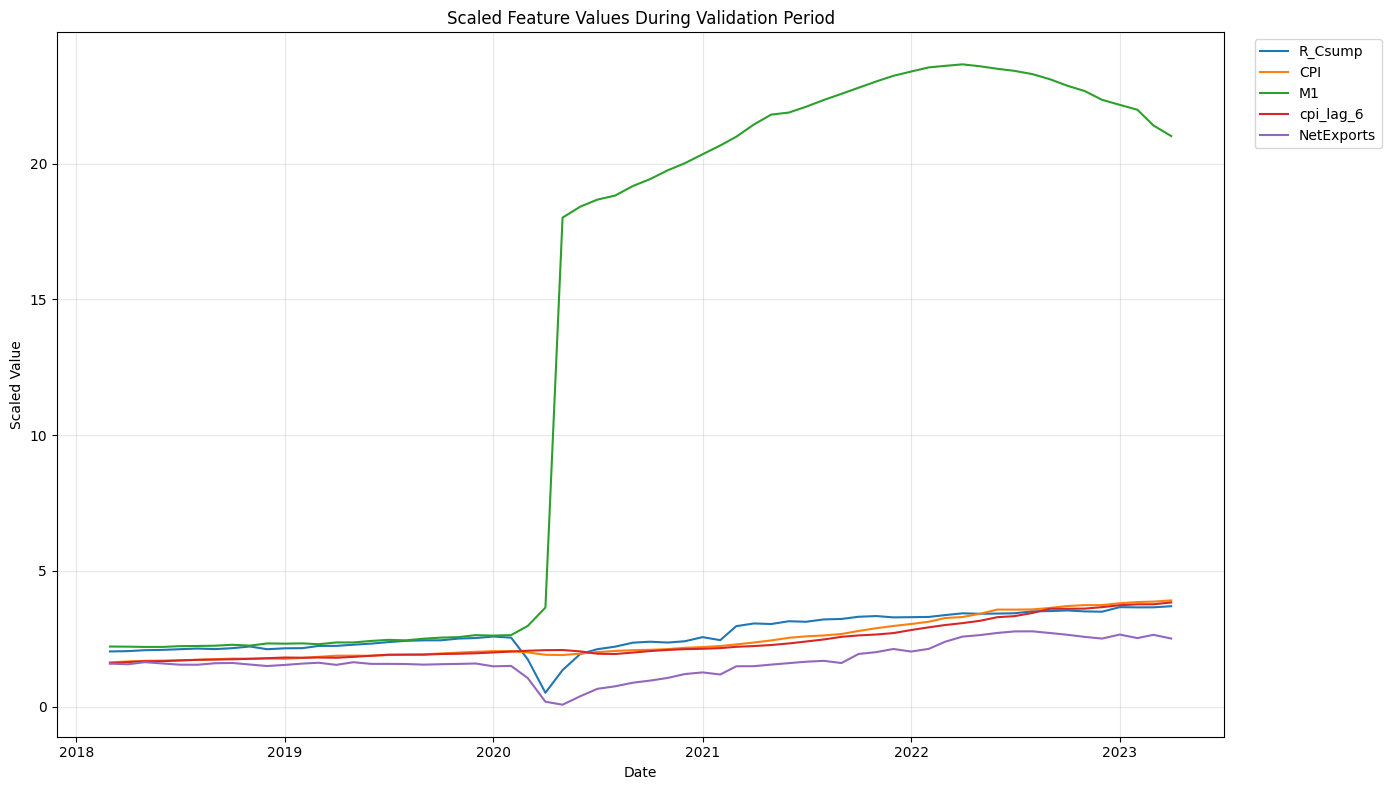

In [69]:
import matplotlib.pyplot as plt

top_features = [
    "R_Csump",
    "CPI",
    "M1",
    "cpi_lag_6",
    "NetExports",

]

val_scaled_plot = X_val_scaled.copy()
val_scaled_plot["DATE"] = dates_val.values
val_scaled_plot = val_scaled_plot.sort_values("DATE").reset_index(drop=True)

plt.figure(figsize=(14, 8))

for col in top_features:
    plt.plot(val_scaled_plot["DATE"], val_scaled_plot[col], label=col, linewidth=1.5)

plt.title("Scaled Feature Values During Validation Period")
plt.xlabel("Date")
plt.ylabel("Scaled Value")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


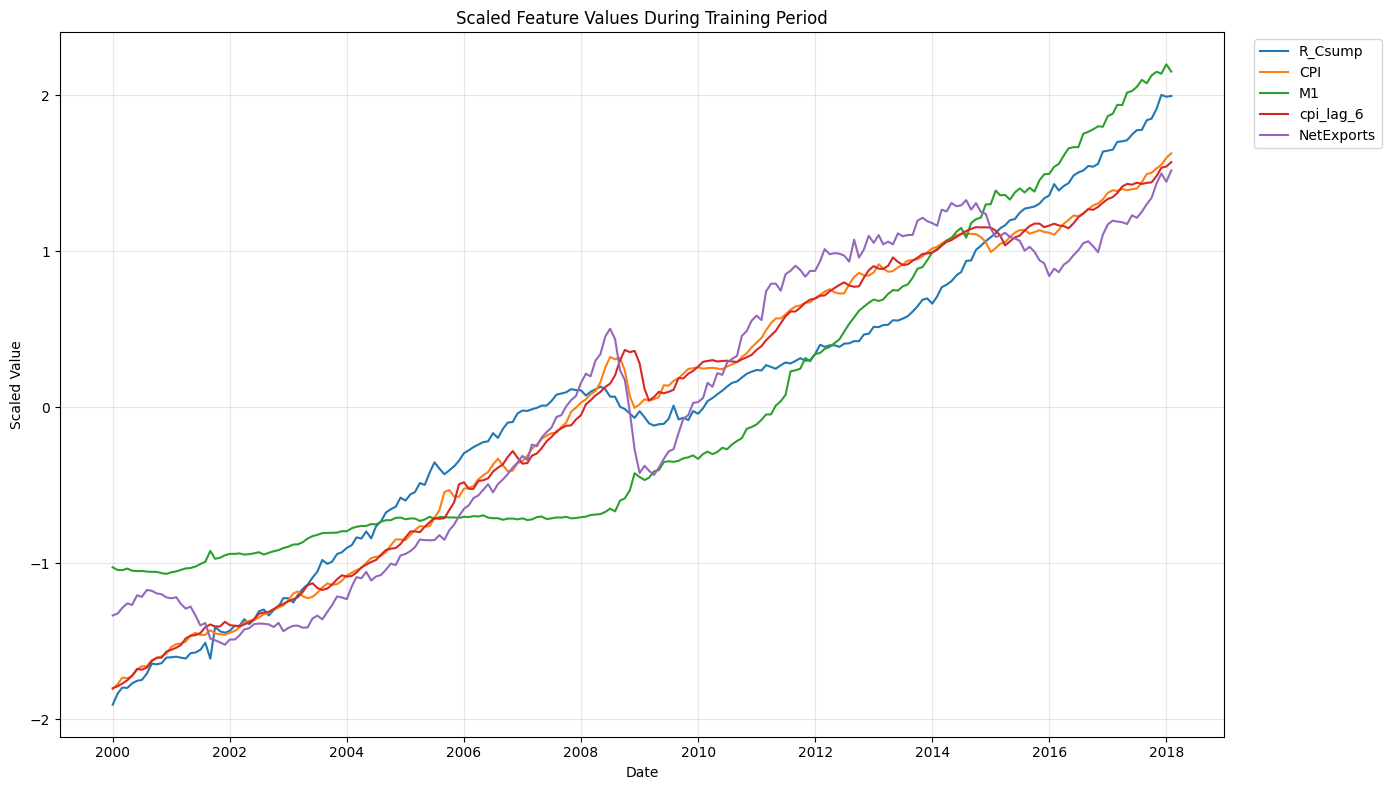

In [70]:
import matplotlib.pyplot as plt

top_features = [
    "R_Csump",
    "CPI",
    "M1",
    "cpi_lag_6",
    "NetExports",
]

top_features = [col for col in top_features if col in X_train_scaled.columns]

train_scaled_plot = X_train_scaled.copy()
train_scaled_plot["DATE"] = dates_train.values
train_scaled_plot = train_scaled_plot.sort_values("DATE").reset_index(drop=True)

plt.figure(figsize=(14, 8))

for col in top_features:
    plt.plot(train_scaled_plot["DATE"], train_scaled_plot[col], label=col, linewidth=1.5)

plt.title("Scaled Feature Values During Training Period")
plt.xlabel("Date")
plt.ylabel("Scaled Value")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
